**Tema:** Estruturação, versionamento e funcionalidade de Código de IA para
solução de engenharia

**Nomes:**
Lorraine Maíra do Nascimento Neto
Sandy Soares Passos
Thasso Caminhas Vieira

**Desafio:** Empresa Anatel - Blindagem para fontes de ruído

**Ideia aplicando IA **: Correção de ruido para o analisador de sinal



Objetivo

Este relatório apresenta uma abordagem para a caracterização e mitigação do ruído identificado, utilizando técnicas de processamento de sinais baseadas em lógica fuzzy. O desenvolvimento de um sistema inteligente de filtragem busca propor a correção do sinal. Inicialmente a empresa Anatel surgiu com o problema real para o projeto de surgimento de ruído ao conectar o carregador do analisador no carregador veicular DC-DC e a antena ao mesmo tempo. Então para esse trabalho computacional da disciplina de IA, aplicou-se a solução de correção desse ruído no sinal de frequência gerado.






In [ ]:
# Instalações
%pip install scikit-fuzzy numpy matplotlib; #Descomente a primeira vez

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

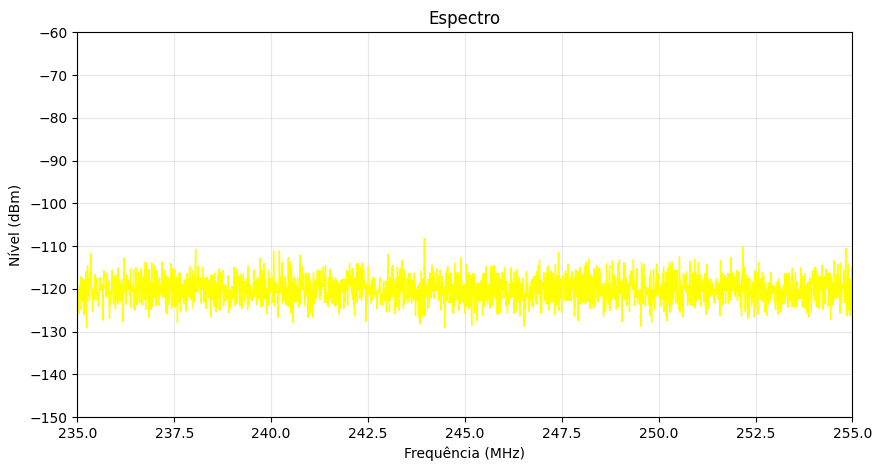

In [ ]:
# Faixa de frequência (MHz)
frequencia = np.linspace(235, 255, 2000)

# Sinal
sinal = -120 + 3 * np.random.randn(len(frequencia))

# Plotagem
plt.figure(figsize=(10,5))
plt.plot(frequencia, sinal, color='yellow', linewidth=1)

plt.title('Espectro')
plt.xlabel('Frequência (MHz)')
plt.ylabel('Nível (dBm)')
plt.grid(True, alpha=0.3)
plt.ylim(-150, -60)
plt.xlim(235, 255)
plt.show()

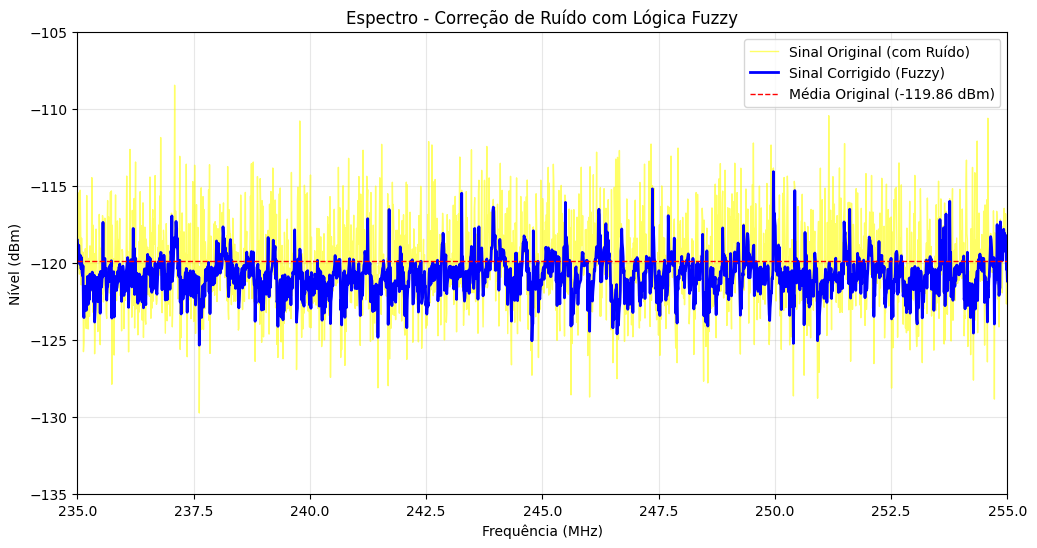


--- Análise de Desempenho da Correção Fuzzy ---
**Desvio Padrão do Sinal Original (Ruído):** 2.9647 dBm
**Desvio Padrão do Sinal Corrigido (Ruído):** 1.2892 dBm
**Redução do Ruído (Desvio Padrão):** 56.51 %


In [ ]:
# --- Reutilização dos Dados da Classificação ---
# Faixa de frequência (MHz)
frequencia = np.linspace(235, 255, 2000)
np.random.seed(42) # Semente para reprodutibilidade
sinal = -120 + 3 * np.random.randn(len(frequencia))
# --- Fim da Reutilização ---

# 1. Definição das Variáveis Fuzzy (Universos Mantidos)
variacao = ctrl.Antecedent(np.arange(0, 15, 0.1), 'variacao')
nivel = ctrl.Antecedent(np.arange(-150, -60, 1), 'nivel')
fator_correcao = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'fator_correcao')

# 2. Definição das Funções de Pertinência (MFs) - Ajuste EXTREMO

# Ajuste 1: A "Alta Variação" começa muito cedo.
variacao['baixa'] = fuzz.trimf(variacao.universe, [0, 0, 1]) # Qualquer variação acima de 1 já é considerada média/alta
variacao['media'] = fuzz.trimf(variacao.universe, [0.5, 3, 6])
variacao['alta'] = fuzz.trimf(variacao.universe, [5, 15, 15]) # Começa em 5

# Ajuste 2: O "Nível Alto" (Picos de Ruído) começa bem perto da média (-120).
nivel['baixo'] = fuzz.trapmf(nivel.universe, [-150, -150, -125, -118])
nivel['normal'] = fuzz.trimf(nivel.universe, [-120, -115, -110]) # Centro em -115
nivel['alto'] = fuzz.trapmf(nivel.universe, [-112, -108, -60, -60]) # Qualquer coisa acima de -112 já é considerada alta

# Ajuste 3: A "Correção Máxima" domina completamente.
fator_correcao['nenhuma'] = fuzz.trimf(fator_correcao.universe, [0, 0, 0.05])
fator_correcao['moderada'] = fuzz.trimf(fator_correcao.universe, [0.0, 0.5, 0.9])
fator_correcao['maxima'] = fuzz.trimf(fator_correcao.universe, [0.8, 1, 1]) # Começa a ser ativa em 0.8

# 3. Definição das Regras Fuzzy (Base de Conhecimento) - MAIS FÁCIL ATIVAR MÁXIMA

# Se a Variação é Baixa E o Nível é Normal -> Correção NENHUMA
regra1 = ctrl.Rule(variacao['baixa'] & nivel['normal'], fator_correcao['nenhuma'])

# Se a Variação é Média OU Alta -> Correção MÁXIMA (Maior cobertura)
regra2 = ctrl.Rule(variacao['media'] | variacao['alta'], fator_correcao['maxima'])

# Se o Nível é Alto (independente da variação) -> Correção MÁXIMA
regra3 = ctrl.Rule(nivel['alto'], fator_correcao['maxima'])

# Se o Nível é Baixo -> Correção MODERADA (Para forçar suavização nos vales)
regra4 = ctrl.Rule(nivel['baixo'], fator_correcao['moderada'])


# 4. Criação do Sistema de Controle e Simulação
sistema_correcao_ctrl = ctrl.ControlSystem([regra1, regra2, regra3, regra4])
sistema_correcao = ctrl.ControlSystemSimulation(sistema_correcao_ctrl)

sinal_corrigido = np.copy(sinal)

# Loop de Inferência Fuzzy e Suavização
for i in range(1, len(sinal)):
    # Entrada 1: Variação Absoluta
    variacao_ponto = np.abs(sinal[i] - sinal[i-1])
    variacao_clip = np.clip(variacao_ponto, variacao.universe.min(), variacao.universe.max())

    # Entrada 2: Nível do Sinal Atual
    nivel_ponto = sinal[i]
    nivel_clip = np.clip(nivel_ponto, nivel.universe.min(), nivel.universe.max())

    sistema_correcao.input['variacao'] = nivel_clip
    sistema_correcao.input['nivel'] = nivel_clip

    sistema_correcao.input['variacao'] = variacao_clip
    sistema_correcao.input['nivel'] = nivel_clip

    try:
        sistema_correcao.compute()
        fator_atual = sistema_correcao.output['fator_correcao']
    except (ValueError, KeyError):
        fator_atual = 0.9 # Correção alta em caso de falha de inferência


    # 5. APLICAÇÃO DA CORREÇÃO
    # Para maior suavização, vamos misturar o ponto atual não apenas com o ponto anterior,
    # mas com uma média dos pontos corrigidos anteriores.

    if i > 1:
        # Ponderação do ponto anterior e do ponto 'média'
        ponto_base = (sinal_corrigido[i-1] + sinal_corrigido[i-2]) / 2
    else:
        ponto_base = sinal_corrigido[i-1]

    # Fórmula de suavização: sinal_corrigido = (1 - fator) * sinal_original + fator * PONTO_BASE
    sinal_corrigido[i] = (1 - fator_atual) * sinal[i] + fator_atual * ponto_base


# 6. Plotagem dos Resultados
plt.figure(figsize=(12,6))
plt.plot(frequencia, sinal, color='yellow', linewidth=1, alpha=0.6, label='Sinal Original (com Ruído)')
plt.plot(frequencia, sinal_corrigido, color='blue', linewidth=2, label='Sinal Corrigido (Fuzzy)')
plt.axhline(np.mean(sinal), color='red', linestyle='--', linewidth=1, label=f'Média Original ({np.mean(sinal):.2f} dBm)')


plt.title('Espectro - Correção de Ruído com Lógica Fuzzy')
plt.xlabel('Frequência (MHz)')
plt.ylabel('Nível (dBm)')
plt.grid(True, alpha=0.3)
plt.ylim(-135, -105)
plt.xlim(235, 255)
plt.legend()
plt.show()

# 7. --- ANÁLISE DE DESEMPENHO ---

# Cálculo dos Desvios Padrão
std_original = np.std(sinal)
std_corrigido = np.std(sinal_corrigido)

# Cálculo da Redução em Porcentagem
if std_original > 0:
    reducao_percentual = ((std_original - std_corrigido) / std_original) * 100
else:
    reducao_percentual = 0

print("\n" + "="*50)
print("--- Análise de Desempenho da Correção Fuzzy ---")
print("="*50)
print(f"**Desvio Padrão do Sinal Original (Ruído):** {std_original:.4f} dBm")
print(f"**Desvio Padrão do Sinal Corrigido (Ruído):** {std_corrigido:.4f} dBm")
print(f"**Redução do Ruído (Desvio Padrão):** {reducao_percentual:.2f} %")
print("="*50)

Limitações

Uma das principais restrições metodológicas reside no caráter essencialmente reativo do algoritmo. O sistema opera sobre o ruído já existente, atuando como um filtro pós-captura, mas não intervém na geração primária das interferências. Esta característica implica que, enquanto a metodologia é eficaz na atenuação dos efeitos, não aborda as causas fundamentais do problema, as quais estão relacionadas com os circuitos eletrônicos do carregador veicular e suas emissões eletromagnéticas intrínsecas.

Resultados

Embora a redução de 56% não represente uma solução completa, a metodologia desenvolvida comprova seu valor como ferramenta de análise e base para soluções mais abrangentes. O sistema fuzzy estabelece um framework válido e adaptável que, quando combinado com outras técnicas, pode levar a soluções definitivas para os problemas de compatibilidade eletromagnética enfrentados pela indústria e órgãos reguladores.